# Day 24 Pre-Class Assignment
---


### <p style="text-align: right;"> &#9989;&nbsp; Put your name here</p>

## Multiple-sample testing against a control group

<img src="https://imgs.xkcd.com/comics/control.png" style="display:block; margin-left: auto; margin-right: auto; width: 30%" alt="In statistics, a confounding variable is a third variable that's related to the independent variable, and also causally related to the dependent variable.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://xkcd.com/790/" target="_blank">xkcd.com</a></p>

### Learning goals for today's pre-class assignment

* Use Dunnett's test for multiple samples against a control in the parametric case
* Use a modified Conover's test in the non-parametric case

## Assignment instructions

**This assignment is due by 11:59 p.m. the day before class,** and should be uploaded into the appropriate "Pre-class assignments" submission folder.  If you run into issues with your code, make sure to use Slack to help each other out and receive some assistance from the instructors. Submission instructions can be found at the end of the notebook.

## Make all the needed imports before anything else

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from matplotlib import pyplot as plt
import scikit_posthocs as posthocs

We will make jitterplots across the assignment (and other plots), so it is good idea to define some variables from the the get-go

In [2]:
# Random noise for the jitterplots
rng = np.random.default_rng(seed = 42)
nudge = rng.uniform(-0.15, 0.15, 1000)

# Lists of colors and markers
colors = ["#a1dab4", "#41b6c4", "#2c7fb8", "#253494", "#ffffcc"]
markers = ['o', '^', 's', 'D', 'v']

# fontsize for all the plots
fs = 12

---

## 1. Kruskal-Wallis omnibus H-test: Contaminated pollen

(We already walked through this whole pipeline in the last pre-class, but here's another example if you need it.)

So far we have been stating rules of thumb of what test to do based on whether the data is normal-ish or not. As a reminder, this is referred to as *parametric* versus *non-parametric* tests.

- **Parametric tests** assume that the data follows a parametric distribution, namely a Normal distribution. A normal distribution can be defined by its two *parameters*: mean and standard deviation.

- **Non-parametric tests** make no such assumption. Usually they convert the data to ranks, in a way very similar to what Spearman does when computing correlation.

In the last class we practiced using parametric omnibus and post hoc tests&mdash;ANOVAs, Tukey's HSD, Games-Howell, and Tamhane's $T_2$. But what if our data is not normal-ish?

The [Kruskal-Wallis H-test](https://en.wikipedia.org/wiki/Kruskal%E2%80%93Wallis_test) is the non-parametric equivalent of ANOVA. It poses the null hypothesis:

> There is no difference among the means of the given samples.


### 1.1 Loading and preparing data

As an example, let's look at the contaminated pollen data from Days 15 and 16. We want to know if alpine skyline flowers report more or less pollen contamination&mdash;relative amount of *Salix* pollen&mdash;depending on the collection site. Or phrased another way: Is there a region in Colorado that is particularly contaminated with *Salix* pollen?

In [3]:
data = pd.read_csv('2016+population+survey.csv')
print(data.shape)
data.head()

(120, 7)


,site,sample ID,meters from Salix,no. flwrs on inflorescence,mean no. pv pollen grains,mean no. Salix pollen,frequency of Salix pollen
0,Pennsylvania Mountain,1.1,6.20,5,314,73,0.188630
1,Pennsylvania Mountain,1.2,4.65,11,187,51,0.214286
2,Pennsylvania Mountain,1.3,15.00,8,241,149,0.382051
3,Pennsylvania Mountain,1.4,18.10,4,185,88,0.322344
4,Pennsylvania Mountain,1.5,11.90,7,129,60,0.317460


Let's make a list with the contamination values, one list item per site. The single-line loop below is Python's shorthand for:

```python
samples = []
for site in sites:
    yvals = data.loc[data['site'] == site, 'frequency of Salix pollen']
    samples.append(  yvals )
```

In [4]:
sites = data['site'].unique()
print('List of unique sites in the data:\n', *sites, sep='; ')

# A list with all contamination values, one list entry per site
samples = [ data.loc[data['site'] == site, 'frequency of Salix pollen'] for site in sites ]

List of unique sites in the data:
; Pennsylvania Mountain; Weston Pass; Hoosier Pass - East; Hoosier Pass - West


### 1.2 Q-Q plots and jitterplots

Remember: testing for normality with Q-Q plots is our bread. Visualizing our data as jitterplots alongside their mean and confidence intervals is our butter.

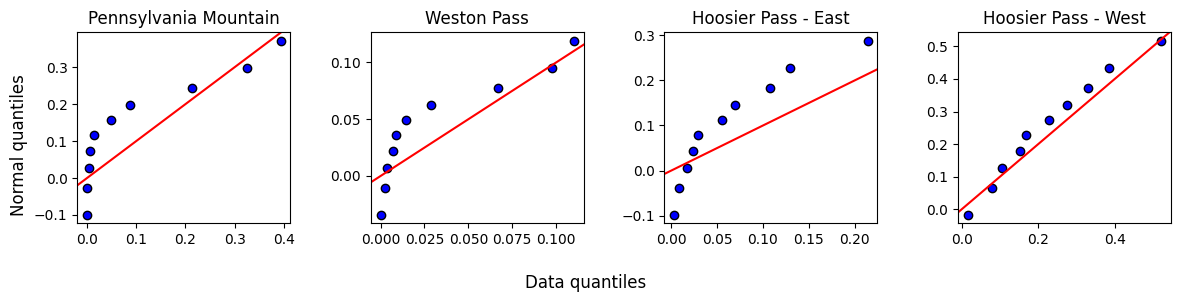

In [5]:
alpha = 0.1
quantiles = np.linspace(alpha, 1-alpha, 10)

fig, ax = plt.subplots(1, len(sites), figsize=(3*len(sites), 3))
for i in range(len(sites)):
        
    dataq = np.quantile(samples[i], quantiles)
    normq = stats.norm.ppf(quantiles, loc=samples[i].mean(), scale=samples[i].std())

    ax[i].scatter(dataq, normq, c='b', ec='k')
    ax[i].axline([dataq[0], dataq[0]], slope=1, c='r')
    ax[i].set_title(sites[i], fontsize=fs)

fig.supxlabel('Data quantiles', fontsize=fs)
fig.supylabel('Normal quantiles', fontsize=fs)
fig.tight_layout()

- Other than Hoosier West, the data does not look normally distributed. We will need a non-parametric procedure.
- Before going further, it always good to visualize the data and the 95% Confidence Intervals. That way, we will know what to expect from the post-hoc analyses.

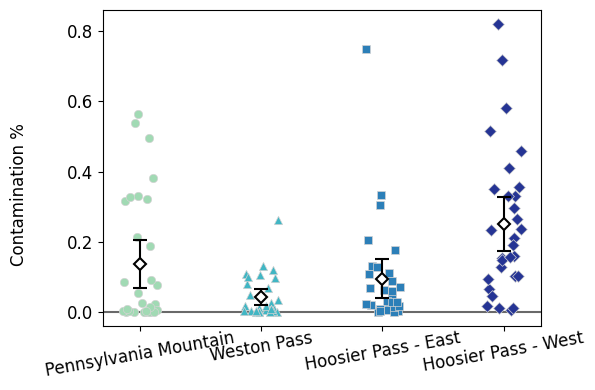

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.axhline(0, c='dimgray', zorder=1)
ax.set_xticks(range(len(sites)), sites, rotation=10, va='center_baseline')
ax.tick_params(labelsize=fs)
for i in range(len(sites)):
    ci = stats.t.ppf(0.975, len(samples[i])-1)*samples[i].sem()
    ax.scatter(i + nudge[:len(samples[i])], samples[i], color=colors[i], marker=markers[i], ec='lightgray', lw=0.5, zorder=2)
    ax.errorbar(i , samples[i].mean(), yerr=ci, color='k', mew=1.5, elinewidth=1.5, capsize=5, mfc='w', marker='D', zorder=3)
    
fig.supylabel('Contamination %', fontsize=fs)
fig.tight_layout()

### 1.3 Does pollen contamination vary by site?

We compute a Kruskal-Wallis H-test [with stats.kruskal](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kruskal.html). Similar to the `stats.tukey_hsd`, notice that this function needs a list with a `*`.

In [7]:
stats.kruskal(*samples)

KruskalResult(statistic=26.119085363308844, pvalue=9.005233512021801e-06)

- Are there any significant differences?

The p-value is small, so we reject the null hypothesis. We might hypothesize that contamination does indeed vary by site. 

However, Kruskal-Wallis does **not** tell us which sites&mdash;if any&mdash;are different from which. One crude posthoc procedure would be to compare all six possible sites with Mann-Whitney tests (because we are doing everything non-parametric) and then adjust p-values with Benjamini-Hochberg to correct for false positives.

But we can consider all samples at once for better results.

### 1.4 Conover's test: non-parametric equivalent for Games-Howell

Unfortunately, `stats` does not do any non-parametric post hoc tests. The good news is that `scikit_posthocs` [has our back](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_conover.html). 

**Conover test does not adjust p-values for false positives automatically!** 

You have to specify that with the `p_adjust` parameter. We'll do `fdr_bh` for the Benjamini-Hochberg procedure.

In [8]:
# Just like with posthoc_tamhane, we get a DataFrame as an output
# We then re-name the columns and indices so it is easier to read what p-value goes with what sites
pvalues = posthocs.posthoc_conover(samples, p_adjust='fdr_bh')
pvalues.columns = sites
pvalues.index = sites
pvalues

,Pennsylvania Mountain,Weston Pass,Hoosier Pass - East,Hoosier Pass - West
Pennsylvania Mountain,1.000000,0.150336,0.720209,0.000380
Weston Pass,0.150336,1.000000,0.089242,0.000001
Hoosier Pass - East,0.720209,0.089242,1.000000,0.000916
Hoosier Pass - West,0.000380,0.000001,0.000916,1.000000


- It seems that Hoosier West is different from the rest of sites.
- These other three sites&mdash;Pennsylvania Mountain, Weston Pass, and Hoosier East&mdash;are similar to each other.
- This observations match the jitterplots.
  
### 1.5 Sidenote: `scikit_posthocs` works with full DataFrames as well

The `scikit_posthocs` test functions behave nicely with full DataFrames&mdash;`stats` test functions prefer lists, arrays, or Series. 

Instead of a list of samples, we can simply give `posthoc_conover` our complete DataFrame and simply tell it which column has the contamination values and which column has the site values. Notice we get the same p-values as above.

In [9]:
# No need to fiddle around with the resulting pvalues dataframe

posthocs.posthoc_conover(data, val_col='frequency of Salix pollen', group_col='site', p_adjust='fdr_bh', sort=False)

,Pennsylvania Mountain,Weston Pass,Hoosier Pass - East,Hoosier Pass - West
Pennsylvania Mountain,1.000000,0.150336,0.720209,0.000380
Weston Pass,0.150336,1.000000,0.089242,0.000001
Hoosier Pass - East,0.720209,0.089242,1.000000,0.000916
Hoosier Pass - West,0.000380,0.000001,0.000916,1.000000


### 1.6 Dunn's test: another alternative (not that different)

Dunn's test is another non-parametric multiple-sample post hoc test. It is also [in `scikit_posthocs`](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_dunn.html). It is a bit worse than Conover but not by thaaat much. Don't lose sleep over which of these two to choose. Just be aware it exists. 

In [10]:
# No need to fiddle around with the resulting pvalues dataframe

posthocs.posthoc_dunn(data, val_col='frequency of Salix pollen', group_col='site', p_adjust='fdr_bh', sort=False)

,Pennsylvania Mountain,Weston Pass,Hoosier Pass - East,Hoosier Pass - West
Pennsylvania Mountain,1.000000,0.200471,0.747994,0.001160
Weston Pass,0.200471,1.000000,0.132852,0.000005
Hoosier Pass - East,0.747994,0.132852,1.000000,0.002496
Hoosier Pass - West,0.001160,0.000005,0.002496,1.000000


And ultimately, our observations with Conover are the same compared to those we drew with Dunn.

### 1.6 Displaying statistical differences in plots

We have already discussed papers where letters are added to barplots/boxplots/jitterplots to indicate that these two samples are the same or different. In fact, Figure 4 from [Kettenbach et al (2017)](https://doi.org/10.1002/ece3.3272) displays these letters. Good news: [`posthocs.compact_letter_display` prints](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.compact_letter_display.html) the letters for us.

- We also add the `.str.strip()` function to remove any trailing, extra white spaces.

In [11]:
cld = posthocs.compact_letter_display(pvalues).str.strip()
cld

Pennsylvania Mountain    a
Weston Pass              a
Hoosier Pass - East      a
Hoosier Pass - West      b
Name: letters, dtype: object

- We can incorporate them to the jitterplot we already had.
- Check how the `ha` and `va` parameters&mdash;horizontal and vertical text alignment, respectively&mdash;[work here](https://matplotlib.org/stable/gallery/text_labels_and_annotations/text_alignment.html).

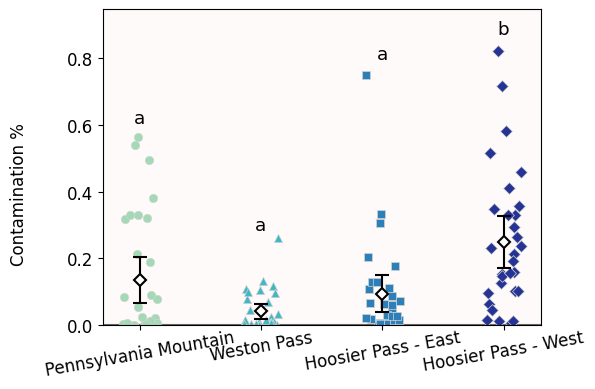

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.set_facecolor('snow')
ax.axhline(0, c='dimgray', zorder=1)
ax.set_xticks(range(len(sites)), sites, rotation=10, va='center_baseline')
ax.tick_params(labelsize=fs)
for i in range(len(sites)):
    ci = stats.t.ppf(0.975, len(samples[i])-1)*samples[i].sem()
    ax.scatter(i + nudge[:len(samples[i])], samples[i], color=colors[i], marker=markers[i], ec='lightgray', lw=0.5, zorder=2)
    ax.errorbar(i , samples[i].mean(), yerr=ci, color='k', mew=1.5, elinewidth=1.5, capsize=5, mfc='w', marker='D', zorder=3)

    # Get the max contamination value for the site, and increase it 5%
    max_pol = samples[i].max()*1.05

    # Print the corresponding letter on top of it
    ax.text(i, max_pol, cld[sites[i]], ha='center', va='bottom', fontsize=1.1*fs)

# Extend the y-axis values so the letters remain within the plot
# First get the current y-axis limits
ylim = ax.get_ylim()

# Set the minimum to 0 (because there are no negative contamination values)
# Increase the maximum by 10%
ax.set_ylim(0, ylim[1]*1.1)

# add a grid
#ax.grid(axis='x', zorder=1)
fig.supylabel('Contamination %', fontsize=fs)
fig.tight_layout()

- I admit that the one downside of jitterplots is that difference letters do not look as good on them compared to barplots/boxplots.

---

## 2. Multiple-sample tests with Control: restored prairies

So far, our multiple-sample tests compare everybody against everybody.

Sometimes, we only want to compare everybody against a common control group. For example, if we have blood pressure drugs A, B, and C, we are only interested in comparing A, B, C against control. We do not really care about comparing A versus B. In such setting, we have dedicated tests:

- **Parametric option**: Dunnett's test
- **Non-parametric option**: Dunn's test [with manual p-value adjustment](https://stats.stackexchange.com/questions/500723/dunn-test-and-specific-comparisons).

### 2.1 Loading and grouping data

For this second example we will use the seed rain and restored praire dataset you used for Homework 04. 

- We load the data
- We group it by `Plot` (prairie restoration age) and sum all the seeds found in each `Transect`

In [13]:
data = pd.read_excel('Seed_Data_2019.xlsx')
total_seeds = data.groupby(['Plot', 'Transect'], as_index=False)['Number'].sum()
total_seeds.head()

,Plot,Transect,Number
0,PFCA 1,1,1705
1,PFCA 1,2,8014
2,PFCA 1,3,8672
3,PFCA 1,4,6770
4,PFCA 1,5,8465


- We do our usual jitterplot visualizaiton

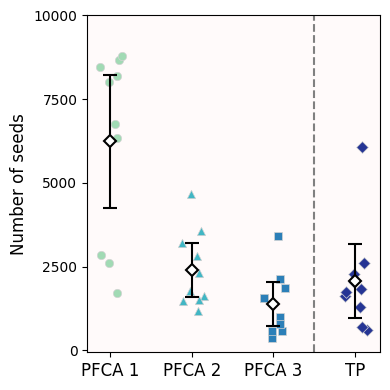

In [14]:
xlabs = total_seeds['Plot'].unique()

fig, ax = plt.subplots(1,1, figsize=(4,4))
for i in range(len(xlabs)):
    y = total_seeds.loc[total_seeds['Plot'] == xlabs[i], 'Number']
    ci = stats.t.ppf(0.975, len(y)-1) * y.sem()
    
    ax.scatter(i + nudge[:len(y)], y, color=colors[i], zorder=1, marker=markers[i], ec='lightgray', lw=0.5)
    ax.errorbar(i , y.mean(), yerr=ci, color='k', mew=1.5, elinewidth=1.5, capsize=5, mfc='w', marker='D', zorder=3)

ax.axvline(2.5, c='gray', ls='dashed')
ax.set_facecolor('snow')
ax.set_yticks(range(0,10001,2500),range(0,10001,2500))
ax.set_xticks(range(len(xlabs)), xlabs, fontsize=fs)
ax.set_ylabel('Number of seeds', fontsize=fs)
fig.tight_layout()

### 2.2 Dunnett's test

In this case, all we care about is comparing restored prairies against a remnant one (control). We are not interested in comparing recently restored praires against older restored praires. And so, we use Dunnett's test&mdash;we are assuming data is normal-ish.

Dunnett already [controls for false positives](https://library.virginia.edu/data/articles/understanding-dunnetts-test), so you don't need to further adjust.

We can use either [the `stats.dunnett`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.dunnett.html) or [the `posthocs_dunnett`](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_dunnett.html) functions. The way you pass the data is different for each though. Here, we'll use the `posthoc_dunnett` version because it accepts whole dataframes.

In [15]:
dunnett = posthocs.posthoc_dunnett(total_seeds, val_col='Number', group_col='Plot', control='TP')
dunnett

,PFCA 1,PFCA 2,PFCA 3,TP
PFCA 1,NaN,NaN,NaN,0.000018
PFCA 2,NaN,NaN,NaN,0.953582
PFCA 3,NaN,NaN,NaN,0.708045
TP,0.000018,0.953582,0.708045,1.0


Notice that the only p-values reported are those comparisons against control

- The young prairies are very different from the remnant ones
- The middle-aged and old prairies are not statistically different from the remnant ones

### 2.3 Another way to showcase significance: `***`

Notice that Figure 1 from [Wynne et al (2024)](https://doi.org/10.1111/1365-2664.14806) does not use letters&mdash;because it is not doing all comparisons&mdash;and instead uses `*` to show which samples are different to control.

We can quickly get a table of stars with [the `posthocs.sign_table` function](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.sign_table.html). As its documentation reads:
- `NS` means not significant, p-value $\geq 0.05$.
- `*` means p-value $< 0.05$
- `**` means p-value $< 0.01$
- `***` means p-value $< 0.001$

I find a bit annoying that you cannot customize the threshold values, but you can define your own function to do this.

In [16]:
stars = posthocs.sign_table(dunnett)
stars

,PFCA 1,PFCA 2,PFCA 3,TP
PFCA 1,-,nan,nan,***
PFCA 2,nan,-,nan,NS
PFCA 3,nan,nan,-,NS
TP,***,NS,NS,-


And repeat the jitterplot, now indicating significance:

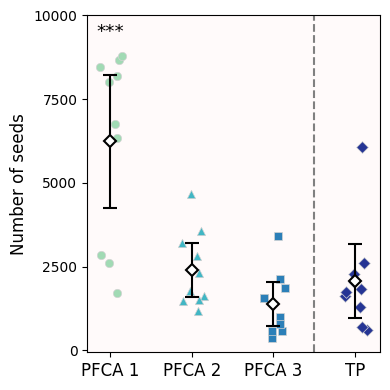

In [17]:
fig, ax = plt.subplots(1,1, figsize=(4,4))
for i in range(len(xlabs)):
    y = total_seeds.loc[total_seeds['Plot'] == xlabs[i], 'Number']
    ci = stats.t.ppf(0.975, len(y)-1) * y.sem()
    
    ax.scatter(i + nudge[:len(y)], y, color=colors[i], zorder=1, marker=markers[i], ec='lightgray', lw=0.5)
    ax.errorbar(i , y.mean(), yerr=ci, color='k', mew=1.5, elinewidth=1.5, capsize=5, mfc='w', marker='D', zorder=3)

# Get the max value and increase it by 5%
max_y = total_seeds['Number'].max()*1.05

# Loop through all prairie types except the last one (remnant)
for i in range(len(xlabs)-1):
    # Only display significant results
    if stars.loc['TP', xlabs[i]] != 'NS':
        ax.text(i, max_y, stars.loc['TP', xlabs[i]], ha='center', va='bottom', fontsize=1.1*fs)

ax.axvline(2.5, c='gray', ls='dashed')
ax.set_facecolor('snow')
ax.set_yticks(range(0,10001,2500),range(0,10001,2500))
ax.set_xticks(range(len(xlabs)), xlabs, fontsize=fs)
ax.set_ylabel('Number of seeds', fontsize=fs)
fig.tight_layout()

### 2.4 Non-parametric alternative: Conover with manual adjustments

Alternatively, we can compute Conover post hoc test **without** initial p-value adjustment (`p_adjust = None`).

In [18]:
conover = posthocs.posthoc_conover(total_seeds, val_col='Number', group_col='Plot', p_adjust=None)
conover

,PFCA 1,PFCA 2,PFCA 3,TP
PFCA 1,1.000000,0.003942,0.000007,0.000432
PFCA 2,0.003942,1.000000,0.035371,0.431797
PFCA 3,0.000007,0.035371,1.000000,0.172664
TP,0.000432,0.431797,0.172664,1.000000


- Since we only care about comparisons against Control (`TP`), we will perform a BH procedure just on the p-values to such.

In [19]:
# The only three p-values we care for
pvals = conover.iloc[:-1, -1]

# Benjamini-Hochberg adjustment
# Put resulting p-value in a Series to keep track of where each pvalue comes from
pvals = pd.Series(stats.false_discovery_control(pvals), pvals.index)
pvals

PFCA 1    0.001297
PFCA 2    0.431797
PFCA 3    0.258996
dtype: float64

- Just like our original jitterplot + 95% Confidence Intervals suggested, only young restored prairies report a different seed rain compared to remnant prairies (p-value < 0.05). As these prairies age, their seed rainfall is comparable to the primeval prairies (p-value > 0.05).

---

## Congratulations, you're done!

Submit this assignment by uploading it to the course Canvas web page.  Go to the "Pre-class assignments" folder, find the appropriate submission folder link, and upload it there.

See you in class!

&#169; Copyright 2026,  Division of Plant Science & Technology&mdash;University of Missouri